In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal,List,Sequence,Annotated

In [2]:
class EmployeeState(TypedDict):
    name: str
    salary: float
    age: int
    decision: Literal['std_hr','forced_hr']
    result: str

In [3]:
def analyze_employee(state: EmployeeState)->EmployeeState:
    """ Doc Comment """
    age = state['age']
    salary = state['salary']
    if age <= 30 and salary <= 40000:
        state['decision'] = 'std_hr'
    else:
        state['decision'] = 'forced_hr'   
    print(f"Employee {state['name']} with age {age} and salary {salary} is assigned to {state['decision']}")     
    return state

In [4]:
def standard_hr_process(state: EmployeeState)->EmployeeState:
    """ Doc Comment """
    state['result'] = f"le dossier de {state['name']} est traité de manière standard"
    print("="*80)
    print(f"le dossier de {state['name']} est traité de manière standard") 
    print("="*80)
    return state

In [5]:
def forced_hr_process(state: EmployeeState)->EmployeeState:
    """ Doc Comment """
    state['result'] = f"le dossier de {state['name']} est traité de manière forcée"
    print("="*80)
    print(f"le dossier de {state['name']} est traité de manière forcée") 
    print("="*80)
    return state

In [6]:
def router(state: EmployeeState)->EmployeeState:
    """ Doc Comment """
    return state['decision']

In [7]:
workflow = StateGraph(EmployeeState)
workflow.add_node("analyze_node",analyze_employee)
workflow.add_node("standard_hr_node",standard_hr_process)
workflow.add_node("forced_hr_node",forced_hr_process)
workflow.add_edge(START,"analyze_node")
workflow.add_conditional_edges(
    "analyze_node",
    router,
    {
        'std_hr': "standard_hr_node",
        'forced_hr': "forced_hr_node"
    }
)
workflow.add_edge("standard_hr_node",END)
workflow.add_edge("forced_hr_node",END)


graph = workflow.compile()

In [8]:
from IPython.display import Image

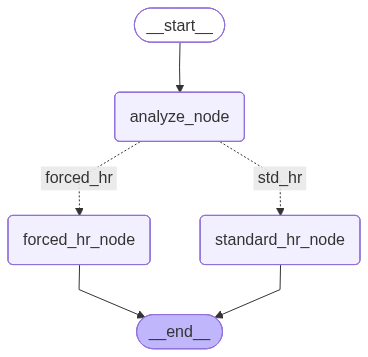

In [9]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
result = graph.invoke({
    'name': 'Nizar',
    'salary': 35000,
    'age': 23
})

Employee Nizar with age 23 and salary 35000 is assigned to std_hr
le dossier de Nizar est traité de manière standard


In [11]:
print(result)

{'name': 'Nizar', 'salary': 35000, 'age': 23, 'decision': 'std_hr', 'result': 'le dossier de Nizar est traité de manière standard'}


In [12]:
result = graph.invoke({
    'name': 'Nizar',
    'salary': 55000,
    'age': 54
})

Employee Nizar with age 54 and salary 55000 is assigned to forced_hr
le dossier de Nizar est traité de manière forcée


In [13]:
print(result)

{'name': 'Nizar', 'salary': 55000, 'age': 54, 'decision': 'forced_hr', 'result': 'le dossier de Nizar est traité de manière forcée'}


In [14]:
from langchain.tools import tool
from langchain.messages import HumanMessage,AIMessage,SystemMessage,ToolMessage
from langchain_core.messages import BaseMessage,AnyMessage
from langgraph.graph import add_messages
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.prebuilt import ToolNode

In [15]:
from dotenv.ipython import load_dotenv
load_dotenv(override=True) 

True

In [16]:
@tool
def add(a: int, b: int) -> int:
    """ Adds two numbers a and b. """
    print(f"Adding {a} and {b}")
    return a + b

In [17]:
@tool
def subtract(a: int, b: int) -> int:
    """ Subtracts b from a. """
    print(f"Subtracting {b} from {a}")
    return a - b

In [18]:
@tool
def multiply(a: int, b: int) -> int:
    """ Multiplies two numbers a and b. """
    print(f"Multiplying {a} and {b}")
    return a * b

In [19]:
@tool
def divide(a: int, b: int) -> float:
    """ Divides a by b. """
    print(f"Dividing {a} by {b}")
    if b == 0:
        raise ValueError("Cannot divide by zero.")
    return a / b

In [20]:
tools = [add, subtract, multiply, divide]

In [21]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage],add_messages]

In [22]:
llm = ChatOpenAI(model="gpt-4o" ,temperature=0)  
llm_with_tools = llm.bind_tools(tools=tools)

In [23]:
def assistant(state: AgentState)->AgentState:
    """ Doc Comment """
    response = llm_with_tools.invoke(state['messages'])   
    print("*"*50)
    print("LLM Invoked") 
    return {"messages":[response]}

In [24]:
def should_continue(state: AgentState):
    """ Doc Comment """
    last_message = state['messages'][-1]
    if not last_message.tool_calls :
        return "end"
    else: 
        return "continue"

In [25]:
workflow = StateGraph(AgentState)
workflow.add_node("assistant_node",assistant)
workflow.add_node("tools_node",ToolNode(tools=tools))
# workflow.add_edge(START,"assistant_node")
workflow.set_entry_point("assistant_node")
workflow.add_conditional_edges(
    "assistant_node",
    should_continue,
    {
        "end": END,
        "continue": "tools_node"
    }
)
workflow.add_edge("tools_node","assistant_node")
memory = InMemorySaver()
graph = workflow.compile(
    checkpointer=memory
)

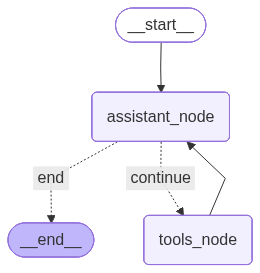

In [26]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [27]:
config = {
    "configurable": {"thread_id":1}
}
response = graph.invoke({
    "messages":[HumanMessage(content="What is the result of (2+3)*4? puis donner moi un proverbe en arabe ") ]
}, config=config)
print(response["messages"][-1].content)

**************************************************
LLM Invoked
Adding 2 and 3
Multiplying 5 and 4
**************************************************
LLM Invoked
Le résultat de \((2+3) \times 4\) est 20.

Un proverbe en arabe : "الصبر مفتاح الفرج" qui signifie "La patience est la clé de la délivrance."


In [28]:
response = graph.invoke({
    "messages":[
        HumanMessage(content="je m'appelle nizar ") 
        ]
}, config=config)
print(response["messages"][-1].content)

**************************************************
LLM Invoked
Enchanté, Nizar ! Si tu as d'autres questions ou si tu as besoin d'aide, n'hésite pas à me le faire savoir.


In [29]:
response = graph.invoke({
    "messages":[
        HumanMessage(content="Comment je m'appelle? ") 
        ]
}, config=config)
print(response["messages"][-1].content)

**************************************************
LLM Invoked
Tu t'appelles Nizar.
